# Ensemble Uncertainty Estimation for Semantic Segmentation

This notebook implements ensemble uncertainty estimation for Mask2Former semantic segmentation using TorchUncertainty.

**Key Features:**
- Sequential model inference for memory efficiency
- TorchUncertainty metrics for uncertainty decomposition
- Per-class IoU and calibration analysis
- Comprehensive uncertainty statistics
- Optional visualization

**Uncertainty Types:**
- **Aleatoric**: Data noise uncertainty
- **Epistemic**: Model disagreement uncertainty  
- **Total**: Combined uncertainty

## 1. Setup and Imports

In [1]:
import os
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore')
plt.style.use('default')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'CUDA device: {torch.cuda.get_device_name(0)}')

PyTorch version: 2.8.0
CUDA available: False


In [2]:
# TorchUncertainty imports
try:
    from torch_uncertainty.metrics.diversity import Entropy, MutualInformation, VariationRatio
    from torch_uncertainty.metrics.calibration import CalibrationError
    from torch_uncertainty.metrics.others import AUSE
    print('✅ TorchUncertainty imported successfully')
    TORCH_UNCERTAINTY_AVAILABLE = True
except ImportError as e:
    print(f'❌ TorchUncertainty import failed: {e}')
    print('Falling back to torchmetrics for IoU calculation.')
    TORCH_UNCERTAINTY_AVAILABLE = False
    try:
        from torchmetrics import JaccardIndex
        print('✅ torchmetrics.JaccardIndex imported for IoU.')
    except ImportError as e2:
        print(f'❌ torchmetrics import failed: {e2}')
        print('Please install: pip install torchmetrics')
        sys.exit(1)

❌ TorchUncertainty import failed: No module named 'torch_uncertainty.metrics.diversity'
Falling back to torchmetrics for IoU calculation.
✅ torchmetrics.JaccardIndex imported for IoU.


In [3]:
# Project imports (adjust paths as needed)
SCRIPT_DIR = os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(SCRIPT_DIR, '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

try:
    from src.models.mask2former import get_mask2former_model, get_preprocessor
    from src.data.coco_dataset import COCODataset, ImageSegmentationDataset
    from src.data.transforms import test_transform, target_transform
    from src.utils.palette import label2id, palette, id2label_remapped, remap_labels
    print('✅ Project modules imported successfully')
except ImportError as e:
    print(f'❌ Project import failed: {e}')
    print('Please ensure your project structure is correct')

✅ Project modules imported successfully


## 2. Configuration

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

CONFIG = {
    'coco_json_path': '/Users/rk/Downloads/Thesis/CKA_sweet_pepper_2020_summer/CKA_sweet_pepper_2020_summer.json',
    'dataset_root_dir': '/Users/rk/Downloads/Thesis/',
    'ensemble_models_dir': 'Output/',
    'output_dir': 'Output/uncertainty_visualizations_notebook',
    'checkpoint_files': [
        'best_model_epoch_27.pt'
    ],
    'batch_size': 3,
    'max_visualize': 10,
    'num_workers': 0
}

if not os.path.exists(CONFIG['coco_json_path']):
    print(f"⚠️  Warning: COCO JSON not found at {CONFIG['coco_json_path']}")
    print('Please update the path in CONFIG above')
else:
    print('✅ COCO dataset path validated')

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print(f"Output directory: {CONFIG['output_dir']}")

num_classes = len(label2id)
print(f'Number of classes: {num_classes}')
print(f'Class mapping: {label2id}')

Using device: cpu
✅ COCO dataset path validated
Output directory: Output/uncertainty_visualizations_notebook
Number of classes: 8
Class mapping: {0: 0, 11: 1, 12: 2, 13: 3, 14: 4, 15: 5, 17: 6, 18: 7}


## 3. Data Loading

In [5]:
print('📁 Loading test dataset...')
base_test_ds = COCODataset(CONFIG['coco_json_path'], CONFIG['dataset_root_dir'], split='test')
test_dataset = ImageSegmentationDataset(base_test_ds, transform=test_transform, target_transform=target_transform, label2id=label2id)
print(f'✅ Test dataset loaded: {len(test_dataset)} samples')

📁 Loading test dataset...
✅ Test dataset loaded: 93 samples
✅ Test dataset loaded: 93 samples


In [6]:
def inference_collate_fn(batch):
    images, masks, orig_images, orig_masks = zip(*batch)
    preprocessor = get_preprocessor(num_classes)
    processed = preprocessor(list(images), segmentation_maps=list(masks), return_tensors='pt')
    return {
        'pixel_values': processed['pixel_values'],
        'original_images': list(orig_images),
        'original_segmentation_maps': list(orig_masks)
    }

test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, collate_fn=inference_collate_fn, num_workers=CONFIG['num_workers'])
print(f'✅ DataLoader created: {len(test_dataloader)} batches')

✅ DataLoader created: 31 batches


🔍 Testing single batch...
Batch shapes:
  - pixel_values: torch.Size([3, 3, 640, 360])
  - original_images: 3
  - original_segmentation_maps: 3
Batch shapes:
  - pixel_values: torch.Size([3, 3, 640, 360])
  - original_images: 3
  - original_segmentation_maps: 3


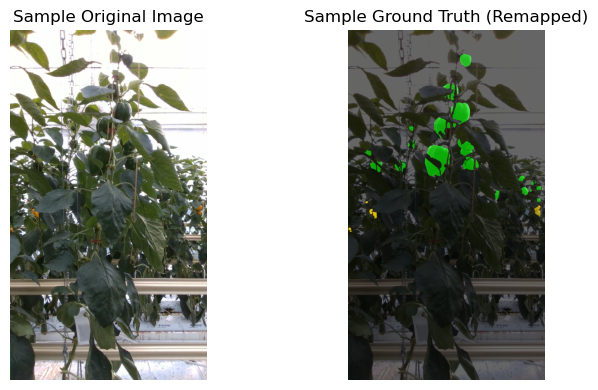

Sample GT shape: torch.Size([1280, 720])
Unique GT labels: [0 3 4 7]


In [8]:
print('🔍 Testing single batch...')
sample_batch = next(iter(test_dataloader))
print(f'Batch shapes:')
print(f'  - pixel_values: {sample_batch["pixel_values"].shape}')
print(f'  - original_images: {len(sample_batch["original_images"])}')
print(f'  - original_segmentation_maps: {len(sample_batch["original_segmentation_maps"])}')
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
orig_img = np.array(sample_batch['original_images'][0])
axes[0].imshow(orig_img)
axes[0].set_title('Sample Original Image')
axes[0].axis('off')
gt_mask = np.array(sample_batch['original_segmentation_maps'][0])
# Remap mask for correct color mapping
remapped_mask = remap_labels(gt_mask, label2id)
custom_cmap = mcolors.ListedColormap(np.array(palette) / 255.0)
axes[1].imshow(orig_img)
axes[1].imshow(remapped_mask, cmap=custom_cmap, alpha=0.6, vmin=0, vmax=len(palette)-1)
axes[1].set_title('Sample Ground Truth (Remapped)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print(f'Sample GT shape: {remapped_mask.shape}')
print(f'Unique GT labels: {np.unique(remapped_mask)}')

In [3]:
# Import necessary libraries
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from PIL import Image
import warnings
import os
from transformers import Mask2FormerForUniversalSegmentation, Mask2FormerImageProcessor, Mask2FormerConfig
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")

# ======================= CONFIGURATION =======================
MODEL_CHECKPOINT_PATH = None
NUM_IMAGES_TO_VISUALIZE = 3
TARGET_LAYER_NAME = "model.pixel_level_module.decoder"
MODEL_NAME = "facebook/mask2former-swin-base-ade-semantic"
# =============================================================

# --- 1. DATA SETUP (CIFAR-10) - CORRECTED ---
print("INFO: Setting up CIFAR-10 dataset...")

processor = Mask2FormerImageProcessor.from_pretrained(MODEL_NAME, do_reduce_labels=False)

CIFAR10_CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                   'dog', 'frog', 'horse', 'ship', 'truck']

num_labels = 10

def collate_fn(batch):
    """Fixed collate function for CIFAR-10."""
    images, labels = zip(*batch)
    
    pil_images = []
    for img in images:
        pil_images.append(img.convert('RGB').resize((512, 512)))
    
    inputs = processor(images=pil_images, return_tensors="pt")
    inputs['original_images'] = pil_images
    inputs['labels'] = list(labels)
    inputs['class_names'] = [CIFAR10_CLASSES[label] for label in labels]
    
    return inputs

# Create CIFAR-10 dataloader - FIXED
try:
    print("Downloading CIFAR-10 dataset...")
    cifar_dataset = CIFAR10(
        root="./data",
        train=False,
        download=True
        # No transform - images are already PIL!
    )
    
    dataloader = DataLoader(
        cifar_dataset, 
        batch_size=NUM_IMAGES_TO_VISUALIZE, 
        shuffle=True, 
        collate_fn=collate_fn
    )
    
    batch = next(iter(dataloader))
    print(f"\n✅ Successfully loaded CIFAR-10 with classes: {batch['class_names']}")
    
except Exception as e:
    print(f"❌ CIFAR-10 loading failed: {e}")
    batch = None

# --- 2. MODEL LOADING ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def get_mask2former_model(num_labels, device):
    config = Mask2FormerConfig.from_pretrained(MODEL_NAME)
    config.num_labels = num_labels
    
    model = Mask2FormerForUniversalSegmentation.from_pretrained(
        MODEL_NAME,
        config=config,
        ignore_mismatched_sizes=True
    )
    
    model.to(device)
    model.eval()
    return model

try:
    model = get_mask2former_model(num_labels, device)
    print("✅ Model loaded successfully.")
except Exception as e:
    print(f"❌ Model loading failed: {e}")
    model = None


INFO: Setting up CIFAR-10 dataset...


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Successfully loaded CIFAR-10 with classes: ['dog', 'dog', 'ship']


Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-base-ade-semantic and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([151]) in the checkpoint and torch.Size([11]) in the model instantiated
- class_predictor.weight: found shape torch.Size([151, 256]) in the checkpoint and torch.Size([11, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([151]) in the checkpoint and torch.Size([11]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded successfully.



🎯 Processing 3 images with fixed layout...

✨ Visualizing feature maps + segmentation for image 1
   Target layer: 'model.pixel_level_module.decoder'
✅ Captured feature maps with shape: torch.Size([256, 48, 48])
   Value range: [-4.451, 5.179]


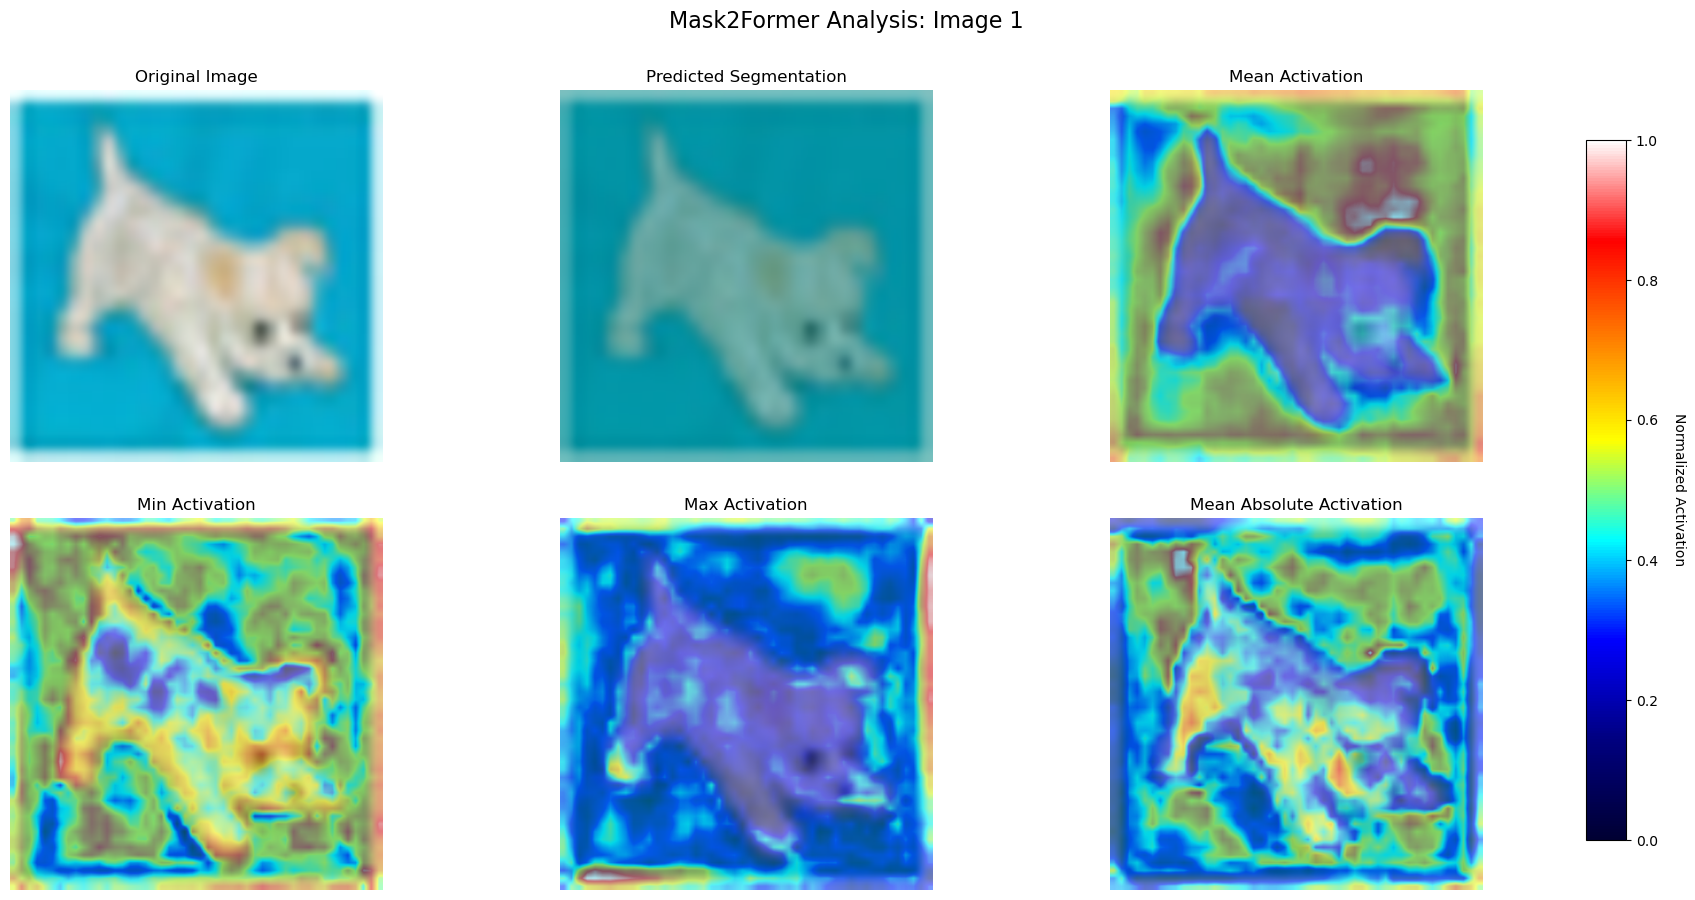

   Predicted classes in segmentation: [6]
   Segmentation shape: (512, 512)

✨ Visualizing feature maps + segmentation for image 2
   Target layer: 'model.pixel_level_module.decoder'
✅ Captured feature maps with shape: torch.Size([256, 48, 48])
   Value range: [-5.312, 4.388]


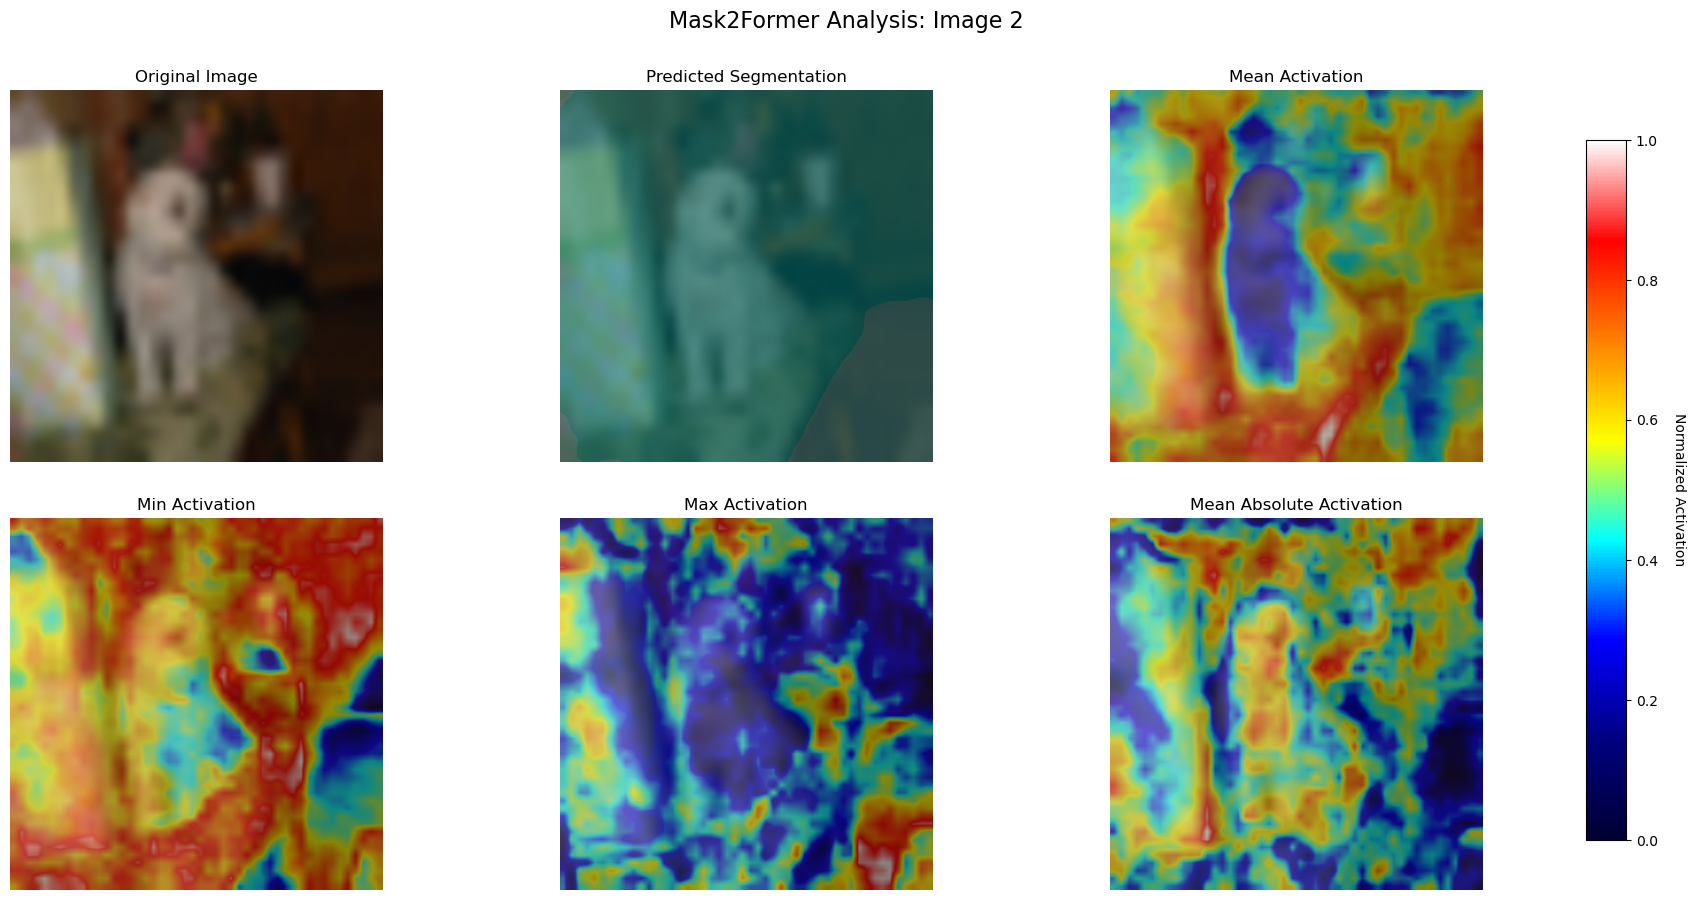

   Predicted classes in segmentation: [3 6]
   Segmentation shape: (512, 512)

✨ Visualizing feature maps + segmentation for image 3
   Target layer: 'model.pixel_level_module.decoder'
✅ Captured feature maps with shape: torch.Size([256, 48, 48])
   Value range: [-4.080, 4.421]


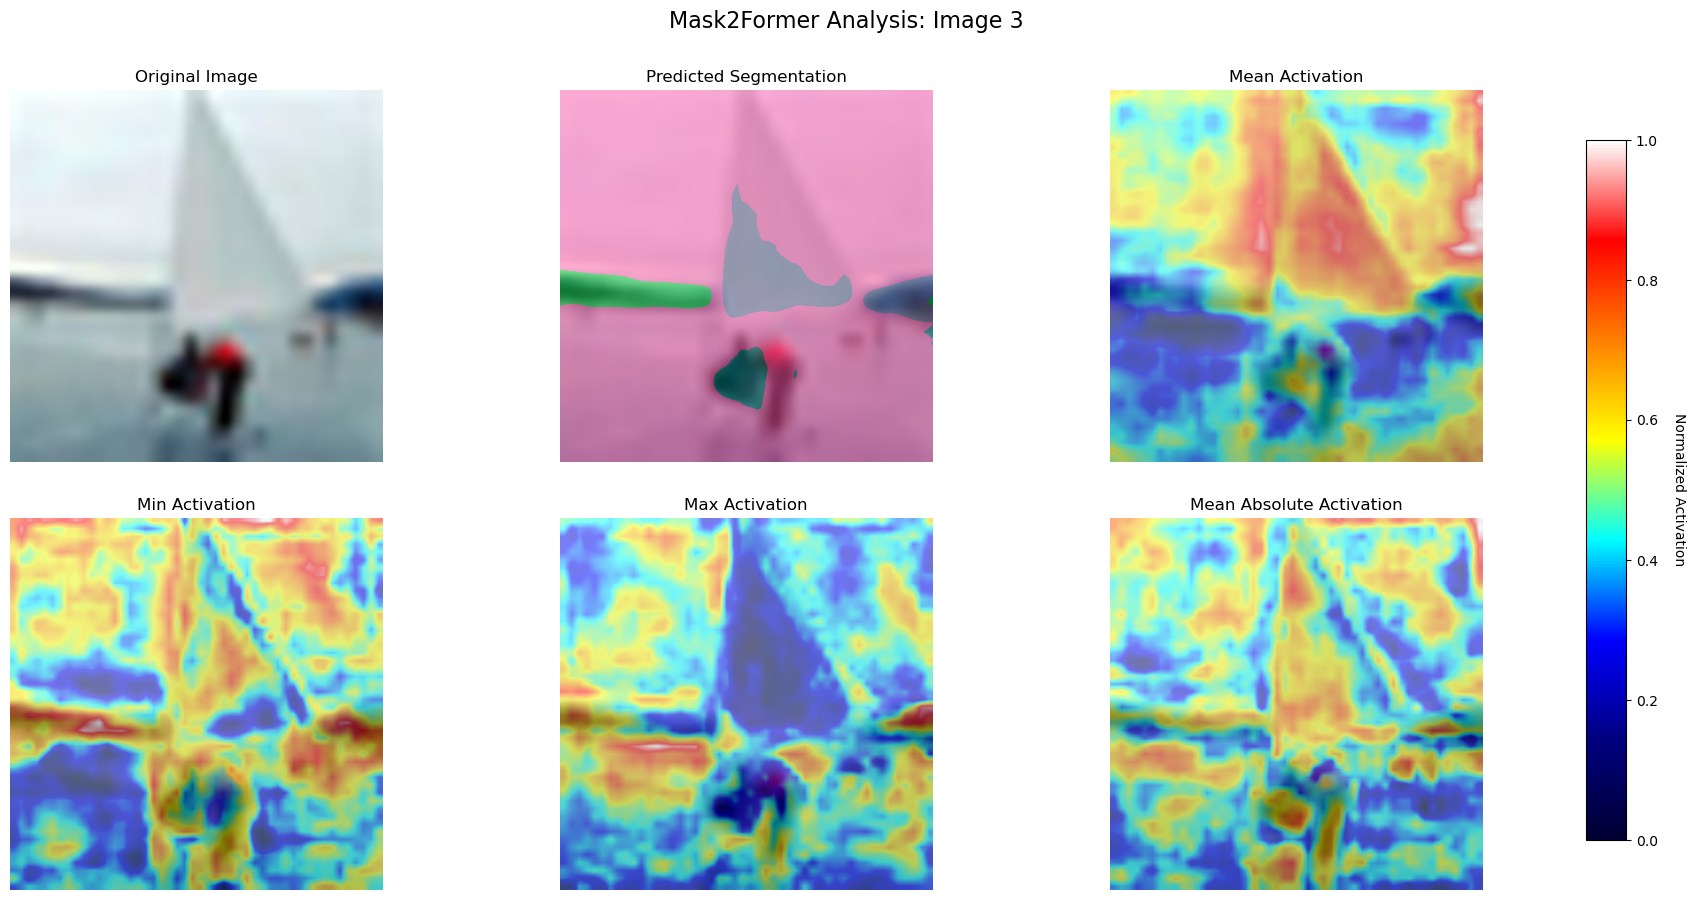

   Predicted classes in segmentation: [1 2 3 9]
   Segmentation shape: (512, 512)


In [4]:
class FeatureMapVisualizer:
    def __init__(self, model, target_layer_name):
        self.model = model
        self.target_layer_name = target_layer_name
        self.feature_maps = None
        self.hook_handle = None
        
        # --- CUSTOM COLORMAPS ---
        uncertainty_colors = ['#000033', '#000080', '#0000FF', '#00FFFF', '#FFFF00', '#FF8000', '#FF0000', '#FFFFFF']
        self.custom_cmap = LinearSegmentedColormap.from_list('custom_uncertainty', uncertainty_colors)
        
        seg_colors = ['#FF0000', '#00FF00', '#0000FF', '#FFFF00', '#FF00FF', '#00FFFF', 
                      '#800000', '#008000', '#000080', '#808000', '#800080', '#008080']
        self.seg_cmap = LinearSegmentedColormap.from_list('segmentation', seg_colors)
    
    def _hook_fn(self, module, input, output):
        """Fixed hook function to handle Mask2FormerPixelDecoderOutput."""
        try:
            if hasattr(output, 'multi_scale_features'):
                if output.multi_scale_features:
                    self.feature_maps = output.multi_scale_features[-1].detach()
                else:
                    self.feature_maps = None
            elif hasattr(output, 'last_hidden_state'):
                self.feature_maps = output.last_hidden_state.detach()
            elif isinstance(output, (list, tuple)):
                if len(output) > 0 and hasattr(output[0], 'detach'):
                    if isinstance(output[0], (list, tuple)) and len(output[0]) > 0:
                        self.feature_maps = output[0][0].detach()
                    else:
                        self.feature_maps = output[0].detach()
                else:
                    self.feature_maps = None
            elif hasattr(output, 'detach'):
                self.feature_maps = output.detach()
            else:
                print(f"   Unexpected output type: {type(output)}")
                self.feature_maps = None
        except Exception as e:
            print(f"   Hook function error: {e}")
            self.feature_maps = None
    
    def _register_hook(self):
        target_layer = dict(self.model.named_modules()).get(self.target_layer_name)
        if target_layer is None:
            raise AttributeError(f"Layer '{self.target_layer_name}' not found in model.")
        self.hook_handle = target_layer.register_forward_hook(self._hook_fn)
    
    def _remove_hook(self):
        if self.hook_handle:
            self.hook_handle.remove()
    
    def _process_segmentation_output(self, outputs, original_size):
        """Process model outputs to get segmentation masks."""
        try:
            predicted_segmentation = processor.post_process_semantic_segmentation(
                outputs, target_sizes=[original_size]
            )[0]
            return predicted_segmentation.cpu().numpy()
        except Exception as e:
            print(f"   Segmentation processing error: {e}")
            return None
    
    def _create_feature_overlay(self, original_image, feature_map):
        """Create feature map overlay."""
        upscaled_map = F.interpolate(
            feature_map.unsqueeze(0).unsqueeze(0),
            size=original_image.size[::-1],
            mode='bilinear',
            align_corners=False
        ).squeeze().cpu().numpy()
        
        norm_map = (upscaled_map - upscaled_map.min()) / (upscaled_map.max() - upscaled_map.min() + 1e-6)
        heatmap = (self.custom_cmap(norm_map)[:, :, :3] * 255).astype(np.uint8)
        heatmap_pil = Image.fromarray(heatmap)
        return Image.blend(original_image, heatmap_pil, alpha=0.5)
    
    def _create_segmentation_overlay(self, original_image, seg_mask):
        """Create segmentation mask overlay."""
        if seg_mask is None:
            return original_image
            
        seg_colored = self.seg_cmap(seg_mask / (seg_mask.max() + 1e-6))
        seg_colored = (seg_colored[:, :, :3] * 255).astype(np.uint8)
        seg_pil = Image.fromarray(seg_colored)
        return Image.blend(original_image, seg_pil, alpha=0.5)
    
    def visualize(self, original_image_pil, pixel_values, image_index=0):
        if not self.model: 
            return
            
        print(f"\n✨ Visualizing feature maps + segmentation for image {image_index + 1}")
        print(f"   Target layer: '{self.target_layer_name}'")
        
        # Register hook and run model
        self._register_hook()
        try:
            with torch.no_grad():
                outputs = self.model(pixel_values.to(device))
        finally:
            self._remove_hook()
        
        # Process segmentation
        original_size = original_image_pil.size
        seg_mask = self._process_segmentation_output(outputs, original_size)
        seg_overlay = self._create_segmentation_overlay(original_image_pil, seg_mask)
        
        # Process feature maps
        feature_overlays = []
        if self.feature_maps is not None:
            try:
                fm = self.feature_maps
                if len(fm.shape) == 4:
                    fm = fm[0]  # Remove batch dimension
                
                if len(fm.shape) == 3:
                    print(f"✅ Captured feature maps with shape: {fm.shape}")
                    print(f"   Value range: [{fm.min():.3f}, {fm.max():.3f}]")
                    
                    # Compute different feature aggregations
                    min_map = torch.min(fm, dim=0)[0]
                    mean_map = torch.mean(fm, dim=0)
                    max_map = torch.max(fm, dim=0)[0]
                    mean_abs_map = torch.mean(torch.abs(fm), dim=0)  # NEW: Mean absolute
                    
                    # Create overlays
                    feature_overlays = [
                        self._create_feature_overlay(original_image_pil, min_map),
                        self._create_feature_overlay(original_image_pil, mean_map),
                        self._create_feature_overlay(original_image_pil, max_map),
                        self._create_feature_overlay(original_image_pil, mean_abs_map)  # NEW
                    ]
                else:
                    print(f"❌ Expected 3D feature map [C, H, W], got shape: {fm.shape}")
            except Exception as e:
                print(f"   Feature processing error: {e}")
        else:
            print("❌ Failed to capture feature maps.")
        
        # FIXED VISUALIZATION LAYOUT
        if feature_overlays:
            # Create figure with proper spacing for colorbar
            fig = plt.figure(figsize=(20, 10))
            
            # Create a grid with space for colorbar
            gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1], height_ratios=[1, 1], 
                                 left=0.05, right=0.85, top=0.9, bottom=0.1, 
                                 wspace=0.1, hspace=0.15)
            
            fig.suptitle(f"Mask2Former Analysis: Image {image_index + 1}", fontsize=16)
            
            # Top row
            ax1 = fig.add_subplot(gs[0, 0])
            ax1.imshow(original_image_pil)
            ax1.set_title("Original Image")
            ax1.axis('off')
            
            ax2 = fig.add_subplot(gs[0, 1])
            ax2.imshow(seg_overlay)
            ax2.set_title("Predicted Segmentation")
            ax2.axis('off')
            
            ax3 = fig.add_subplot(gs[0, 2])
            ax3.imshow(feature_overlays[1])  # Mean features
            ax3.set_title("Mean Activation")
            ax3.axis('off')
            
            # Bottom row
            ax4 = fig.add_subplot(gs[1, 0])
            ax4.imshow(feature_overlays[0])  # Min features
            ax4.set_title("Min Activation")
            ax4.axis('off')
            
            ax5 = fig.add_subplot(gs[1, 1])
            ax5.imshow(feature_overlays[2])  # Max features
            ax5.set_title("Max Activation")
            ax5.axis('off')
            
            ax6 = fig.add_subplot(gs[1, 2])
            ax6.imshow(feature_overlays[3])  # NEW: Mean absolute features
            ax6.set_title("Mean Absolute Activation")
            ax6.axis('off')
            
            # Add properly positioned colorbar
            cbar_ax = fig.add_axes([0.87, 0.15, 0.02, 0.7])
            norm = plt.Normalize(vmin=0, vmax=1)
            sm = plt.cm.ScalarMappable(cmap=self.custom_cmap, norm=norm)
            sm.set_array([])
            cbar = fig.colorbar(sm, cax=cbar_ax)
            cbar.set_label('Normalized Activation', rotation=270, labelpad=20)
            
        else:
            # Fallback: Just segmentation
            fig, axes = plt.subplots(1, 2, figsize=(12, 6))
            fig.suptitle(f"Mask2Former Segmentation: Image {image_index + 1}", fontsize=16)
            
            axes[0].imshow(original_image_pil)
            axes[0].set_title("Original Image")
            axes[0].axis('off')
            
            axes[1].imshow(seg_overlay)
            axes[1].set_title("Predicted Segmentation")
            axes[1].axis('off')
            
            plt.tight_layout()
        
        plt.show()
        
        # Print statistics
        if seg_mask is not None:
            unique_classes = np.unique(seg_mask)
            print(f"   Predicted classes in segmentation: {unique_classes}")
            print(f"   Segmentation shape: {seg_mask.shape}")

# --- USAGE REMAINS THE SAME ---
if model and batch:
    try:
        visualizer = FeatureMapVisualizer(model, target_layer_name=TARGET_LAYER_NAME)
        
        num_in_batch = len(batch['pixel_values'])
        images_to_process = min(NUM_IMAGES_TO_VISUALIZE, num_in_batch)
        
        print(f"\n🎯 Processing {images_to_process} images with fixed layout...")
        print("=" * 60)
        
        for i in range(images_to_process):
            pixel_values_single = batch['pixel_values'][i:i+1]
            original_image_data = batch['original_images'][i]
            if isinstance(original_image_data, np.ndarray):
                original_image_pil = Image.fromarray(original_image_data)
            else:
                original_image_pil = original_image_data
            
            visualizer.visualize(original_image_pil, pixel_values_single, image_index=i)
            
    except Exception as e:
        print(f"❌ An error occurred during visualization. Error: {e}")
